# INF6422E – Advanced Concepts in Computer Security  
## Practical Work 2 – Winter 2026  

### Adversarial Machine Learning and Robustness Evaluation

--- 
  
## Students  
- Antoine Khoueiry – *Matricule:* 2487137  
- Louis Junior Mpandzo-Otiankouya – *Matricule:* 2421549  

---

## Objective

This lab explores adversarial machine learning, where attackers manipulate input data in order to fool machine learning–based security systems. We implement adversarial attacks and defenses, and quantitatively evaluate the robustness of deep learning models trained on the CIFAR-10 dataset.  
Adversarial threats are highly relevant in cybersecurity, as modern intrusion detection systems, malware classifiers, and biometric authentication models increasingly rely on machine learning. Understanding robustness is therefore essential for deploying trustworthy AI-powered security solutions.

---

## Dataset

**CIFAR-10**: 60,000 colour images (32×32) across 10 classes, with 6,000 images per class.  
Source: https://www.cs.toronto.edu/~kriz/cifar.html

---

## Notebook Structure

1. Baseline Machine Learning Classification Model  
2. Adversarial Evasion Attacks (Test-Time Threats)  
3. Data Poisoning Attacks (Training-Time Threats)  
4. Defenses and Robustness Trade-Offs


# 1. Baseline Machine Learning Classification Model

## 1.1 Dataset Preparation and Training Pipeline 


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from collections import defaultdict
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import label_binarize

# ── Device ───────────────────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define data directories
data_dir = r'Datasets'

# Data transformation
data_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),  # Adding vertical flip
    transforms.RandomRotation(20),    # Adding random rotation
    transforms.RandomAffine(15),      # Adding random affine transformation
    transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Using device: cuda


In [3]:
# Load datasets
full_train = datasets.CIFAR10(root=data_dir, train=True, download=True, transform=data_transform)
test_dataset  = datasets.CIFAR10(root=data_dir, train=False, download=True, transform=data_transform)
combined_dataset = ConcatDataset([full_train, test_dataset])

# Split the dataset into train, validation, and test sets
train_size = int(0.7 * len(combined_dataset))
val_size = int(0.15 * len(combined_dataset))
test_size = len(combined_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(combined_dataset, [train_size, val_size, test_size])

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(f"Train : {len(train_dataset):>6} images")
print(f"Val   : {len(val_dataset):>6} images")
print(f"Test  : {len(test_dataset):>6} images")

Files already downloaded and verified
Files already downloaded and verified
Train :  42000 images
Val   :   9000 images
Test  :   9000 images


### Dataset Split Justification

Following the professor's instructions, the full CIFAR-10 dataset (60,000 images) is **first merged** then split into **70 % training / 15 % validation / 15 % test**, yielding 42,000 / 9,000 / 9,000 images respectively.

Merging before splitting ensures that the class distribution is uniform across all three sets (each set sees the same proportion of each class), and that the split ratios are computed over the true full dataset rather than just the original training portion.

- **Training set (70 % — 42,000 images)** provides sufficient examples for the CNN to learn discriminative visual features across all 10 CIFAR-10 classes.
- **Validation set (15 % — 9,000 images)** is held out during training and used exclusively to monitor generalisation and tune hyperparameters (learning rate, number of epochs, architecture choices). Without a separate validation set, hyperparameter selection would implicitly incorporate test-set information, leading to optimistic performance estimates.
- **Test set (15 % — 9,000 images)** is only used **once** after training to produce final, unbiased metrics. In security contexts this mirrors the principle of evaluating a deployed IDS on truly unseen traffic.

This three-way split is the standard methodology in machine learning and is especially important in adversarial ML, where models must generalise to previously unseen perturbations.

## 1.2 CNN Model Training

In [4]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3,   out_channels=32,  kernel_size=3, stride=1, padding=1)
        self.conv2 = nn.Conv2d(in_channels=32,  out_channels=64,  kernel_size=3, stride=1, padding=1)
        self.conv3 = nn.Conv2d(in_channels=64,  out_channels=128, kernel_size=3, stride=1, padding=1)
        self.conv4 = nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=1, padding=1)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1     = nn.Linear(256 * 2 * 2, 512)
        self.fc2     = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)
        self.relu    = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))   # 32×32 → 16×16
        x = self.pool(self.relu(self.conv2(x)))   # 16×16 →  8×8
        x = self.pool(self.relu(self.conv3(x)))   #  8×8  →  4×4
        x = self.pool(self.relu(self.conv4(x)))   #  4×4  →  2×2
        x = x.view(x.size(0), -1)                 # flatten → 256*2*2 = 1024
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = SimpleCNN(num_classes=10).to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

SimpleCNN(
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1024, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)

Trainable parameters: 918,346


In [8]:
model.to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 30
scheduler  = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

train_losses = []
val_losses = []
val_accuracies = []

best_val_acc  = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    train_loss = running_loss / len(train_loader)
    train_losses.append(train_loss)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    class_correct = defaultdict(int)
    class_total = defaultdict(int)

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            for i in range(len(labels)):
                label = labels[i].item()
                pred = predicted[i].item()
                if label == pred:
                    class_correct[label] += 1
                class_total[label] += 1

    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)

    val_accuracy = 100 * correct / total
    val_accuracies.append(val_accuracy)

    # Save best model
    if val_accuracy > best_val_acc:
        best_val_acc = val_accuracy
        torch.save(model.state_dict(), 'best_model.pth')

    scheduler.step()

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Accuracy: {val_accuracy:.2f}%")

    for class_idx in range(len(class_total)):
        accuracy = 100 * class_correct[class_idx] / class_total[class_idx]
        print(f"Validation Accuracy for class {class_idx}: {accuracy:.2f}%")

print(f"\nBest validation accuracy: {best_val_acc:.2f}%")


Epoch 1/30, Train Loss: 1.3891, Val Loss: 1.3412, Val Accuracy: 52.04%
Validation Accuracy for class 0: 48.26%
Validation Accuracy for class 1: 68.81%
Validation Accuracy for class 2: 41.39%
Validation Accuracy for class 3: 33.07%
Validation Accuracy for class 4: 56.20%
Validation Accuracy for class 5: 33.18%
Validation Accuracy for class 6: 61.62%
Validation Accuracy for class 7: 49.48%
Validation Accuracy for class 8: 61.98%
Validation Accuracy for class 9: 64.52%
Epoch 2/30, Train Loss: 1.3797, Val Loss: 1.3370, Val Accuracy: 52.76%
Validation Accuracy for class 0: 52.37%
Validation Accuracy for class 1: 66.74%
Validation Accuracy for class 2: 32.25%
Validation Accuracy for class 3: 31.69%
Validation Accuracy for class 4: 48.37%
Validation Accuracy for class 5: 62.46%
Validation Accuracy for class 6: 51.07%
Validation Accuracy for class 7: 57.79%
Validation Accuracy for class 8: 66.97%
Validation Accuracy for class 9: 56.06%
Epoch 3/30, Train Loss: 1.3607, Val Loss: 1.3239, Val Accu

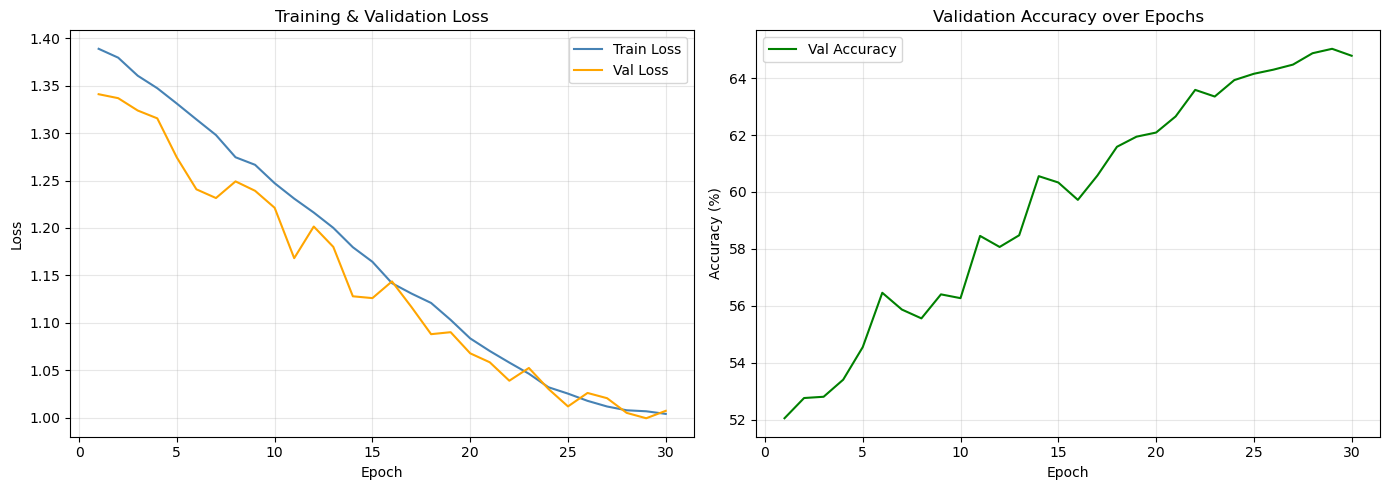

In [9]:
epochs_range = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs_range, train_losses, label='Train Loss', color='steelblue')
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   color='orange')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, val_accuracies, label='Val Accuracy', color='green')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Validation Accuracy over Epochs')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [21]:
# Load the best model
model = SimpleCNN(num_classes=10)
model.load_state_dict(torch.load('best_model.pth', weights_only=True))

model.to(device)

model.eval()

# Evaluate on the test set
correct = 0
total = 0
class_correct = defaultdict(int)
class_total = defaultdict(int)

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)  # Move data to GPU
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            label = labels[i].item()
            pred = predicted[i].item()
            if label == pred:
                class_correct[label] += 1
            class_total[label] += 1

test_accuracy = 100 * correct / total
print(f"Test Accuracy: {test_accuracy:.2f}%")

for class_idx in range(len(class_total)):
    accuracy = 100 * class_correct[class_idx] / class_total[class_idx]
    class_name = full_train.classes[class_idx]  # Access through dataset wrapper
    print(f"Test Accuracy for {class_name}: {accuracy:.2f}%")

Test Accuracy: 63.89%
Test Accuracy for airplane: 65.69%
Test Accuracy for automobile: 80.05%
Test Accuracy for bird: 49.56%
Test Accuracy for cat: 39.68%
Test Accuracy for deer: 63.37%
Test Accuracy for dog: 54.50%
Test Accuracy for frog: 74.43%
Test Accuracy for horse: 64.48%
Test Accuracy for ship: 76.09%
Test Accuracy for truck: 71.72%


In [ ]:
# Get predictions and calculate probabilities for ROC and Precision-Recall curves
all_labels = []
all_outputs = []
all_outputs_proba = []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        all_labels.extend(labels.cpu().numpy())
        all_outputs.extend(predicted.cpu().numpy())
        all_outputs_proba.extend(outputs.cpu().numpy())

all_labels = np.array(all_labels)
all_outputs = np.array(all_outputs)
all_outputs_proba = np.array(all_outputs_proba)

# Get class names from the original dataset
class_names = full_train.classes

<class 'list'>


Normalized confusion matrix


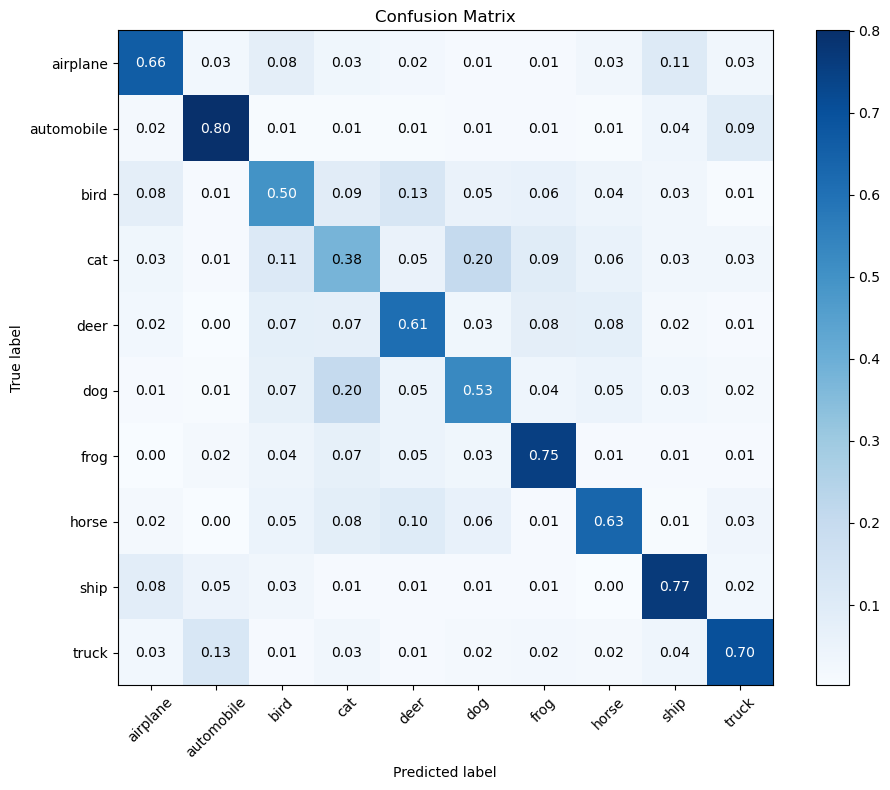

Classification Report:
               precision    recall  f1-score   support

    airplane       0.70      0.66      0.68       921
  automobile       0.76      0.80      0.78       877
        bird       0.52      0.50      0.51       910
         cat       0.38      0.38      0.38       872
        deer       0.59      0.61      0.60       939
         dog       0.56      0.53      0.55       945
        frog       0.68      0.75      0.72       884
       horse       0.67      0.63      0.65       870
        ship       0.71      0.77      0.74       891
       truck       0.73      0.70      0.72       891

    accuracy                           0.63      9000
   macro avg       0.63      0.63      0.63      9000
weighted avg       0.63      0.63      0.63      9000



In [23]:
# Confusion Matrix
cm = confusion_matrix(all_labels, all_outputs)
def plot_confusion_matrix(cm, classes, normalize=True, title='Confusion matrix', cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.figure(figsize=(10, 8))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in np.ndindex(cm.shape):
        plt.text(j, i, format(cm[i, j], fmt), ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(cm, classes=class_names, title='Confusion Matrix')

# Classification Report
class_report = classification_report(all_labels, all_outputs, target_names=class_names, zero_division=0)
print("Classification Report:\n", class_report)

# Binarize labels for ROC and Precision-Recall curves
y_test_binarized = label_binarize(all_labels, classes=np.arange(len(class_names)))
if y_test_binarized.shape[1] == 1:
    y_test_binarized = np.hstack([1 - y_test_binarized, y_test_binarized])

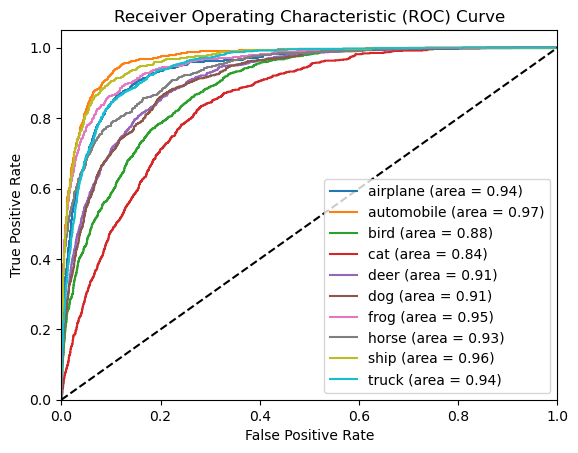

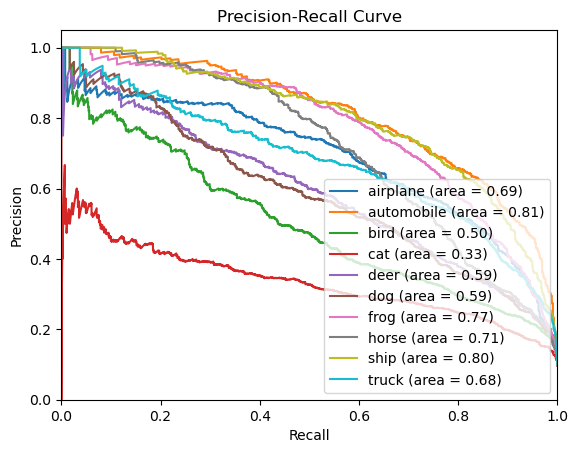

In [24]:
def plot_roc_curve_multiclass(y_true, y_pred_proba, n_classes, class_names):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true[:, i], y_pred_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    plt.figure()
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], label=f'{class_names[i]} (area = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    plt.show()

def plot_precision_recall_curve_multiclass(y_true, y_pred_proba, n_classes, class_names):
    precision = dict()
    recall = dict()
    pr_auc = dict()

    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true[:, i], y_pred_proba[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    plt.figure()
    for i in range(n_classes):
        plt.plot(recall[i], precision[i], label=f'{class_names[i]} (area = {pr_auc[i]:.2f})')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='lower right')
    plt.show()

# Plot ROC curve for each class
plot_roc_curve_multiclass(y_test_binarized, all_outputs_proba, len(class_names), class_names)

# Plot Precision-Recall curve for each class
plot_precision_recall_curve_multiclass(y_test_binarized, all_outputs_proba, len(class_names), class_names)

---
# 2. Adversarial Evasion Attacks (Test-Time Threats)

Evasion attacks occur **at inference time**: the attacker crafts an input that looks normal to a human but fools the classifier. The two attacks implemented here are:

| Attack | Type | Steps |
|--------|------|-------|
| **FGSM** (Fast Gradient Sign Method) | One-step | 1 |
| **PGD** (Projected Gradient Descent) | Iterative | 5–40 |

Both operate in the *white-box* threat model: the attacker has full access to the model parameters and gradients.

## 2.1 FGSM Attack Implementation


In [25]:
def fgsm_attack(image, epsilon, data_grad):
    """
    Generate an adversarial example using FGSM.

    """
    sign_grad        = data_grad.sign()
    perturbed_image  = image + epsilon * sign_grad
    # Clip to the valid normalised range for CIFAR-10
    # Pixel-wise bounds derived from [0,1] after channel normalisation
    perturbed_image  = torch.clamp(perturbed_image, -3, 3)   # generous bound in normalised space
    return perturbed_image


def evaluate_fgsm(model, loader, epsilon, criterion, device, n_batches=50):
    """
    Run FGSM on the first `n_batches` batches and return accuracy + collected
    adversarial images/labels for visualisation.
    """
    model.eval()
    correct, total = 0, 0
    adv_images_saved, clean_images_saved, labels_saved = [], [], []

    for batch_idx, (inputs, labels) in enumerate(loader):
        if batch_idx >= n_batches:
            break
        inputs, labels = inputs.to(device), labels.to(device)
        inputs.requires_grad = True

        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()

        data_grad   = inputs.grad.data
        adv_inputs  = fgsm_attack(inputs, epsilon, data_grad)

        with torch.no_grad():
            adv_outputs = model(adv_inputs)
            _, predicted = torch.max(adv_outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

        if batch_idx == 0:          # save first batch for visualisation
            adv_images_saved  = adv_inputs.detach().cpu()
            clean_images_saved = inputs.detach().cpu()
            labels_saved       = labels.cpu()

    accuracy = 100 * correct / total if total > 0 else 0.0
    return accuracy, adv_images_saved, clean_images_saved, labels_saved

print("FGSM attack function defined.")

FGSM attack function defined.


In [30]:
# ── Evaluate FGSM at multiple epsilon values ─────────────────────────────
epsilons = [0.00, 0.01, 0.03, 0.05, 0.10, 0.20]
fgsm_accuracies = []

# Reload best model to ensure clean state
model_eval = SimpleCNN(num_classes=10).to(device)
model_eval.load_state_dict(torch.load('best_model.pth', map_location=device, weights_only=True))

print(f"{'Epsilon':>10} | {'Accuracy (%)':>14}")
print("-" * 28)

vis_adv, vis_clean, vis_labels = None, None, None

for eps in epsilons:
    acc, adv_imgs, clean_imgs, lbls = evaluate_fgsm(
        model_eval, test_loader, eps, criterion, device, n_batches=50
    )
    fgsm_accuracies.append(acc)
    print(f"{eps:>10.2f} | {acc:>14.2f}%")
    if eps == 0.05:          # save ε=0.05 images for visualisation
        vis_adv, vis_clean, vis_labels = adv_imgs, clean_imgs, lbls

   Epsilon |   Accuracy (%)
----------------------------
      0.00 |          63.56%
      0.01 |          23.69%
      0.03 |           5.75%
      0.05 |           2.12%
      0.10 |           1.94%
      0.20 |           3.31%


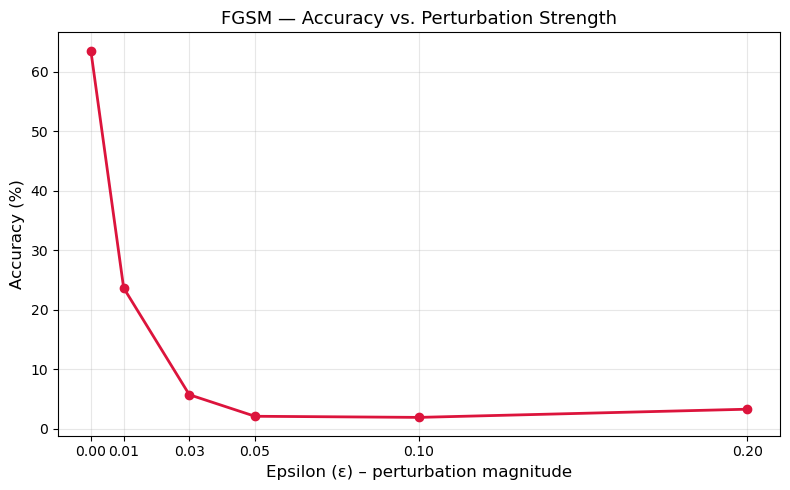

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(epsilons, fgsm_accuracies, marker='o', color='crimson', linewidth=2)
plt.xlabel('Epsilon (ε) – perturbation magnitude', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('FGSM — Accuracy vs. Perturbation Strength', fontsize=13)
plt.xticks(epsilons)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fgsm_accuracy_drop.png', dpi=150)
plt.show()

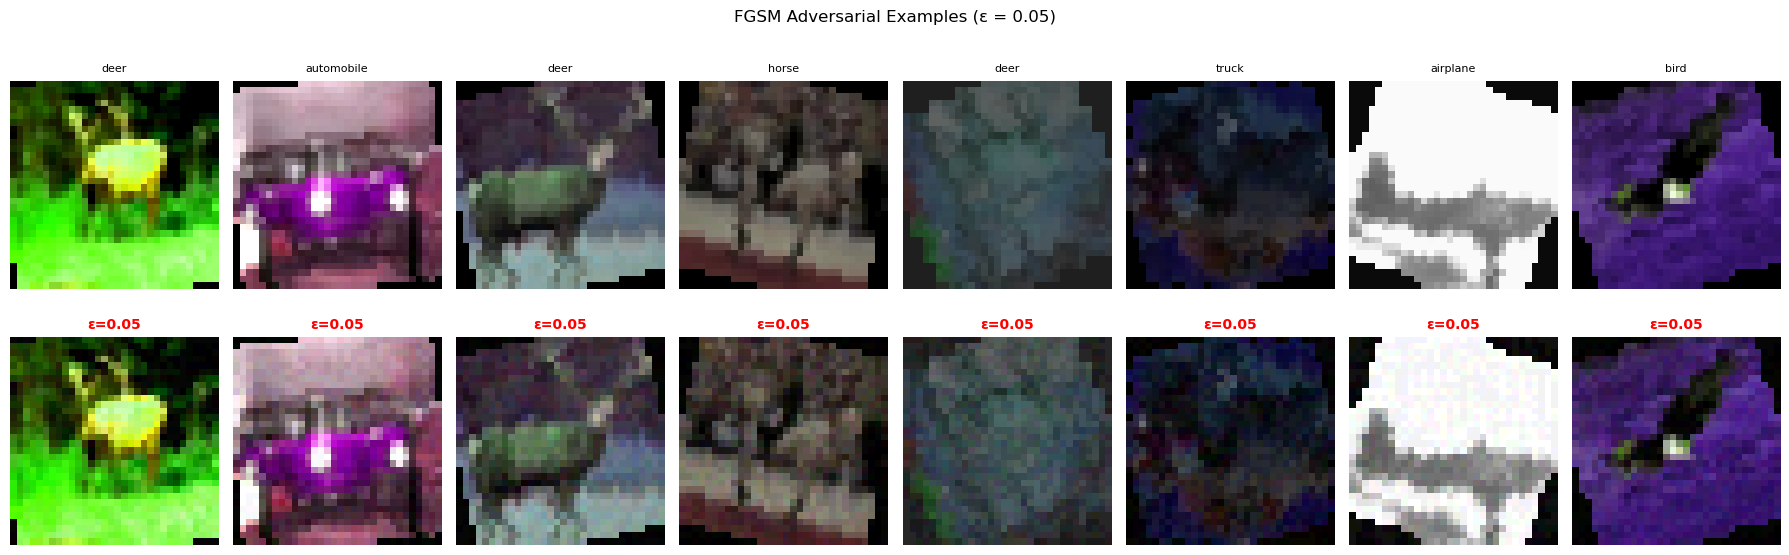

In [40]:
def denorm(tensor):
    """Reverse CIFAR-10 normalisation to [0,1] for display."""
    mean = torch.tensor((0.5, 0.5, 0.5)).view(3,1,1)
    std  = torch.tensor((0.5, 0.5, 0.5)).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

n_show = 8
fig, axes = plt.subplots(2, n_show, figsize=(18, 6))

for col in range(n_show):
    clean_img = denorm(vis_clean[col]).permute(1, 2, 0).numpy()
    adv_img   = denorm(vis_adv[col]).permute(1, 2, 0).numpy()
    true_lbl  = class_names[vis_labels[col].item()]

    axes[0, col].imshow(clean_img)
    axes[0, col].set_title(f'{true_lbl}', fontsize=8)
    axes[0, col].axis('off')

    axes[1, col].imshow(adv_img)
    axes[1, col].set_title(f'ε=0.05', fontsize=10, color='red', weight='bold', )
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('Clean', fontsize=10)
axes[1, 0].set_ylabel('Adversarial', fontsize=10)
plt.suptitle('FGSM Adversarial Examples (ε = 0.05)', fontsize=12)
plt.tight_layout()
plt.savefig('fgsm_examples.png', dpi=150)
plt.show()

## 2.2 PGD Attack Implementation

# 3. Data Poisoning Attacks (Training-Time Threats)

## 3.1 Label-Flipping Poisoning Experiment

The simplest poisoning strategy is **label flipping**: randomly selecting a fraction of training samples and assigning them an incorrect label. This simulates a supply-chain attack on the training dataset (e.g., a malicious insider corrupting network traffic logs used to train an IDS).

We experiment with two poisoning rates:
- **5 %** of training labels flipped
- **15 %** of training labels flipped

In [ ]:
import copy
import random as pyrandom
from torch.utils.data import Dataset

class PoisonedDataset(Dataset):
    """
    Wraps an existing dataset and flips `poison_rate` fraction of labels
    to a random different class (uniform over the other 9 classes).

    Parameters
    ----------
    dataset     : original torch Dataset
    poison_rate : float in [0, 1]
    seed        : int for reproducibility
    """
    def __init__(self, dataset, poison_rate=0.05, seed=SEED):
        self.dataset      = dataset
        self.poison_rate  = poison_rate
        self.n_classes    = 10

        # Collect all labels
        self.targets = [dataset[i][1] for i in range(len(dataset))]

        # Choose which indices to poison
        pyrandom.seed(seed)
        n_poison = int(len(self.targets) * poison_rate)
        self.poisoned_indices = set(pyrandom.sample(range(len(self.targets)), n_poison))

        # Flip labels
        self.poisoned_targets = list(self.targets)
        for idx in self.poisoned_indices:
            original = self.poisoned_targets[idx]
            # Choose a random class different from the original
            choices = list(range(self.n_classes))
            choices.remove(original)
            self.poisoned_targets[idx] = pyrandom.choice(choices)

        n_actually_flipped = sum(
            1 for i in self.poisoned_indices
            if self.poisoned_targets[i] != self.targets[i]
        )
        print(f"Poison rate: {poison_rate*100:.0f}%  |  "
              f"Indices selected: {len(self.poisoned_indices)}  |  "
              f"Labels flipped: {n_actually_flipped}")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, _ = self.dataset[idx]
        return image, self.poisoned_targets[idx]


def train_poisoned_model(train_dataset, val_loader, poison_rate,
                          device, num_epochs=15, seed=SEED):
    """
    Create a poisoned training set, train a fresh CNN on it,
    and return the trained model + per-epoch histories.
    """
    poisoned_train = PoisonedDataset(train_dataset, poison_rate=poison_rate, seed=seed)
    poisoned_loader = DataLoader(poisoned_train, batch_size=32,
                                  shuffle=True, num_workers=2)

    model_p   = SimpleCNN(num_classes=10).to(device)
    criterion_p = nn.CrossEntropyLoss()
    optimizer_p = optim.Adam(model_p.parameters(), lr=0.001)
    scheduler_p = optim.lr_scheduler.CosineAnnealingLR(optimizer_p, T_max=num_epochs)

    train_losses_p, val_losses_p, val_accs_p = [], [], []

    for epoch in range(num_epochs):
        model_p.train()
        running_loss = 0.0
        for inputs, labels in poisoned_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer_p.zero_grad()
            outputs = model_p(inputs)
            loss    = criterion_p(outputs, labels)
            loss.backward()
            optimizer_p.step()
            running_loss += loss.item()

        train_loss = running_loss / len(poisoned_loader)
        train_losses_p.append(train_loss)

        # Validate on clean val set
        model_p.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model_p(inputs)
                val_loss += criterion_p(outputs, labels).item()
                _, predicted = torch.max(outputs, 1)
                correct += (predicted == labels).sum().item()
                total   += labels.size(0)

        val_loss = val_loss / len(val_loader)
        val_losses_p.append(val_loss)
        val_accs_p.append(100 * correct / total)

        scheduler_p.step()
        print(f"  Epoch {epoch+1:02d}/{num_epochs}  "
              f"Train Loss: {train_loss:.4f}  Val Acc: {val_accs_p[-1]:.2f}%")

    return model_p, train_losses_p, val_losses_p, val_accs_p

print("Poisoning utilities defined.")

Poisoning utilities defined.


In [ ]:
POISON_EPOCHS = 15   # fewer epochs to keep runtime reasonable

print("=" * 60)
print("Training on CLEAN data (baseline reference)")
print("=" * 60)
# Re-train a clean reference model with the same number of epochs
model_clean_ref = SimpleCNN(num_classes=10).to(device)
crit_ref  = nn.CrossEntropyLoss()
optim_ref = optim.Adam(model_clean_ref.parameters(), lr=0.001)
sched_ref = optim.lr_scheduler.CosineAnnealingLR(optim_ref, T_max=POISON_EPOCHS)
clean_val_accs = []
for epoch in range(POISON_EPOCHS):
    model_clean_ref.train()
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optim_ref.zero_grad()
        loss = crit_ref(model_clean_ref(inputs), labels)
        loss.backward(); optim_ref.step()
    model_clean_ref.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            _, preds = torch.max(model_clean_ref(inputs), 1)
            correct += (preds == labels).sum().item(); total += labels.size(0)
    clean_val_accs.append(100 * correct / total)
    sched_ref.step()
    print(f"  Epoch {epoch+1:02d}/{POISON_EPOCHS}  Val Acc: {clean_val_accs[-1]:.2f}%")

print()
print("=" * 60)
print("Training on POISONED data — poison rate = 5 %")
print("=" * 60)
model_p5, tl_p5, vl_p5, va_p5 = train_poisoned_model(
    train_dataset, val_loader, poison_rate=0.05,
    device=device, num_epochs=POISON_EPOCHS
)

print()
print("=" * 60)
print("Training on POISONED data — poison rate = 15 %")
print("=" * 60)
model_p15, tl_p15, vl_p15, va_p15 = train_poisoned_model(
    train_dataset, val_loader, poison_rate=0.15,
    device=device, num_epochs=POISON_EPOCHS
)

Training on CLEAN data (baseline reference)
  Epoch 01/15  Val Acc: 60.11%
  Epoch 02/15  Val Acc: 69.77%
  Epoch 03/15  Val Acc: 72.28%
  Epoch 04/15  Val Acc: 73.63%
  Epoch 05/15  Val Acc: 74.13%
  Epoch 06/15  Val Acc: 74.26%
  Epoch 07/15  Val Acc: 74.77%
  Epoch 08/15  Val Acc: 76.04%
  Epoch 09/15  Val Acc: 76.12%
  Epoch 10/15  Val Acc: 76.73%
  Epoch 11/15  Val Acc: 76.48%
  Epoch 12/15  Val Acc: 76.76%
  Epoch 13/15  Val Acc: 77.01%
  Epoch 14/15  Val Acc: 77.23%
  Epoch 15/15  Val Acc: 77.10%

Training on POISONED data — poison rate = 5 %
Poison rate: 5%  |  Indices selected: 2100  |  Labels flipped: 2100
  Epoch 01/15  Train Loss: 1.6187  Val Acc: 54.98%
  Epoch 02/15  Train Loss: 1.2402  Val Acc: 64.29%
  Epoch 03/15  Train Loss: 1.0672  Val Acc: 69.48%
  Epoch 04/15  Train Loss: 0.9306  Val Acc: 72.18%
  Epoch 05/15  Train Loss: 0.8186  Val Acc: 71.93%
  Epoch 06/15  Train Loss: 0.6851  Val Acc: 72.73%
  Epoch 07/15  Train Loss: 0.5567  Val Acc: 73.49%
  Epoch 08/15  Trai

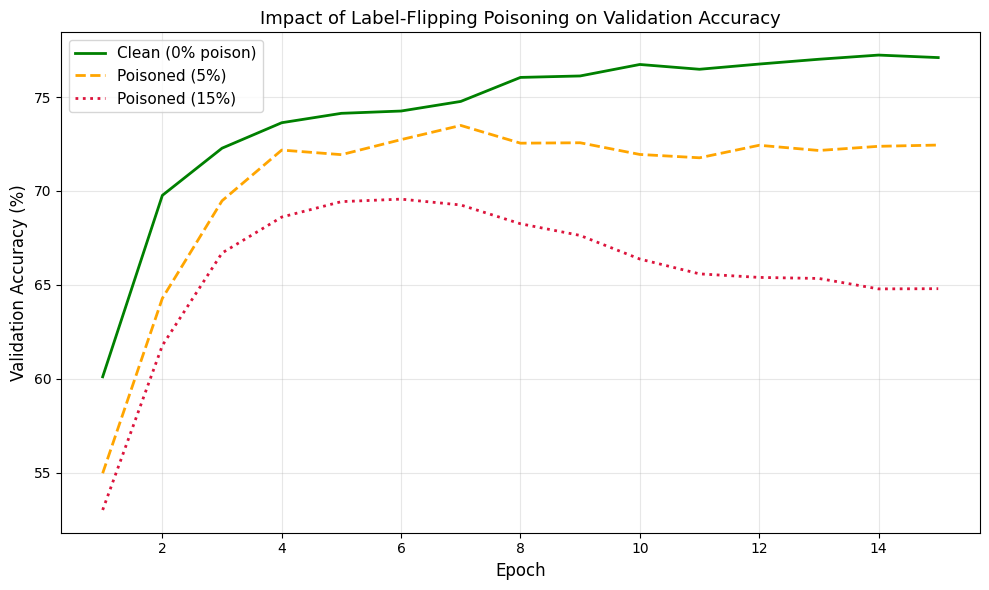


Final Validation Accuracy:
  Clean (0 %) : 77.10%
  Poisoned 5% : 72.44%
  Poisoned 15%: 64.80%


In [ ]:
epochs_p = range(1, POISON_EPOCHS + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_p, clean_val_accs, label='Clean (0% poison)',  color='green',    linewidth=2)
plt.plot(epochs_p, va_p5,          label='Poisoned (5%)',       color='orange',   linewidth=2, linestyle='--')
plt.plot(epochs_p, va_p15,         label='Poisoned (15%)',      color='crimson',  linewidth=2, linestyle=':')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Validation Accuracy (%)', fontsize=12)
plt.title('Impact of Label-Flipping Poisoning on Validation Accuracy', fontsize=13)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('poisoning_val_accuracy.png', dpi=150)
plt.show()

print(f"\nFinal Validation Accuracy:")
print(f"  Clean (0 %) : {clean_val_accs[-1]:.2f}%")
print(f"  Poisoned 5% : {va_p5[-1]:.2f}%")
print(f"  Poisoned 15%: {va_p15[-1]:.2f}%")

## 3.2 Quantitative Poisoning Impact

*(To be completed — clean accuracy vs. poisoned accuracy comparison table and analysis.)*

In [ ]:
#Test accuracy is computed on the clean test set to quantify the impact of data poisoning.

def evaluate_accuracy(model, data_loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in data_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100.0 * correct / total

In [ ]:
# Compute test accuracy for clean and poisoned models and measure the accuracy drop

clean_test_acc = evaluate_accuracy(model_clean_ref, test_loader, device)
p5_test_acc    = evaluate_accuracy(model_p5,        test_loader, device)
p15_test_acc   = evaluate_accuracy(model_p15,       test_loader, device)

print("\n=== Section 3.2 — Quantitative Poisoning Impact (TEST ACCURACY) ===")
print(f"Clean Test Accuracy (0% poison):   {clean_test_acc:.2f}%")
print(f"Poisoned Test Accuracy (5%):       {p5_test_acc:.2f}%")
print(f"Poisoned Test Accuracy (15%):      {p15_test_acc:.2f}%")
print("\nAccuracy Drop vs Clean:")
print(f"Drop @ 5%  = {clean_test_acc - p5_test_acc:.2f} points")
print(f"Drop @ 15% = {clean_test_acc - p15_test_acc:.2f} points")


=== Section 3.2 — Quantitative Poisoning Impact (TEST ACCURACY) ===
Clean Test Accuracy (0% poison):   77.30%
Poisoned Test Accuracy (5%):       72.43%
Poisoned Test Accuracy (15%):      65.46%

Accuracy Drop vs Clean:
Drop @ 5%  = 4.87 points
Drop @ 15% = 11.84 points


In [ ]:
# Create a summary table for clean vs poisoned test accuracy
import pandas as pd

results_32 = pd.DataFrame({
    "Training Condition": ["Clean (0%)", "Poisoned (5%)", "Poisoned (15%)"],
    "Test Accuracy (%)": [clean_test_acc, p5_test_acc, p15_test_acc],
    "Accuracy Drop (points)": [0.0, clean_test_acc - p5_test_acc, clean_test_acc - p15_test_acc],
})

results_32

,Training Condition,Test Accuracy (%),Accuracy Drop (points)
0,Clean (0%),77.300000,0.000000
1,Poisoned (5%),72.433333,4.866667
2,Poisoned (15%),65.455556,11.844444


The results show that even a small poisoning rate significantly degrades the reliability of the model. A 5% label corruption causes a drop of 4.87 accuracy points, while 15% leads to an 11.84-point decrease.
In security-critical systems such as intrusion detection systems or malware classifiers, this degradation directly translates into undetected attacks. A poisoned model may still appear to perform normally on standard evaluation data, which creates a false sense of security for analysts and automated defense pipelines. This is particularly dangerous because operational trust in these systems is based on their consistency and high detection rates. Once the training pipeline is compromised, the model learns incorrect decision boundaries and systematically ignores specific malicious patterns. As a result, defenders rely on outputs that are biased, and this enables stealthy persistence for attackers and undermines the integrity of the entire cyber-defense.

# 4. Baseline Machine Learning Classification Model

## 4.1 Dataset Preparation and Training Pipeline 

*(To be completed)*


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd


#───FGSM attack (simple)────

# Generate FGSM adversarial examples from a batch of input images (x) and labels (y).

def fgsm_attack(model, x, y, epsilon=0.03):

    x = x.clone().detach().requires_grad_(True)

    logits = model(x)
    loss = nn.CrossEntropyLoss()(logits, y)

    model.zero_grad(set_to_none=True)
    loss.backward()

    x_adv = x + epsilon * x.grad.sign()
    return x_adv.detach()


#────Robust accuracy────

def evaluate_accuracy(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return 100.0 * correct / total

def evaluate_robust_accuracy_fgsm(model, loader, device, epsilon=0.03):
    model.eval()
    correct, total = 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        # Create adversarial examples
        x_adv = fgsm_attack(model, x, y, epsilon=epsilon)

        with torch.no_grad():
            preds = model(x_adv).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return 100.0 * correct / total


#─────Adversarial training─────
def adversarial_train_fgsm(model, train_loader, val_loader, device,
                           epsilon=0.03, epochs=5, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for ep in range(1, epochs + 1):
        model.train()
        running_loss = 0.0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            # Generate adversarial batch with current model
            x_adv = fgsm_attack(model, x, y, epsilon=epsilon)

            optimizer.zero_grad(set_to_none=True)
            logits = model(x_adv)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # (Optional) clean validation accuracy during training
        val_acc = evaluate_accuracy(model, val_loader, device)
        print(f"[AdvTrain FGSM] Epoch {ep:02d}/{epochs} | "
              f"TrainLoss {running_loss/len(train_loader):.4f} | "
              f"ValAcc(clean) {val_acc:.2f}%")

    return model


#─────Run Q4.1 (Before vs After) ──────

EPSILON = 0.03
ADV_EPOCHS = 10

# ---- BEFORE defense ----
baseline_model = model_clean_ref

clean_before  = evaluate_accuracy(baseline_model, test_loader, device)
robust_before = evaluate_robust_accuracy_fgsm(baseline_model, test_loader, device, epsilon=EPSILON)

print("\n=== BEFORE Adversarial Training ===")
print(f"Clean Test Accuracy:  {clean_before:.2f}%")
print(f"Robust Accuracy (FGSM, eps={EPSILON}): {robust_before:.2f}%")

# ---- Train defended model (fresh model) ----
model_defended = SimpleCNN(num_classes=10).to(device)
model_defended = adversarial_train_fgsm(model_defended, train_loader, val_loader, device,
                                        epsilon=EPSILON, epochs=ADV_EPOCHS, lr=1e-3)

# ---- AFTER defense ----
clean_after  = evaluate_accuracy(model_defended, test_loader, device)
robust_after = evaluate_robust_accuracy_fgsm(model_defended, test_loader, device, epsilon=EPSILON)

print("\n=== AFTER Adversarial Training ===")
print(f"Clean Test Accuracy:  {clean_after:.2f}%")
print(f"Robust Accuracy (FGSM, eps={EPSILON}): {robust_after:.2f}%")
print(f"Robust Accuracy Improvement: {robust_after - robust_before:.2f} points")


# ---- Deliverable table ----
q4_results = pd.DataFrame({
    "Setting": ["Before adversarial training", "After adversarial training"],
    "Clean Test Accuracy (%)": [clean_before, clean_after],
    f"Robust Accuracy (%) [FGSM eps={EPSILON}]": [robust_before, robust_after],
    "Robust Accuracy Improvement (points)": [0.0, robust_after - robust_before]
})

q4_results



=== BEFORE Adversarial Training ===
Clean Test Accuracy:  77.30%
Robust Accuracy (FGSM, eps=0.03): 36.24%
[AdvTrain FGSM] Epoch 01/10 | TrainLoss 1.7119 | ValAcc(clean) 54.82%
[AdvTrain FGSM] Epoch 02/10 | TrainLoss 1.4092 | ValAcc(clean) 59.02%
[AdvTrain FGSM] Epoch 03/10 | TrainLoss 1.2746 | ValAcc(clean) 63.93%
[AdvTrain FGSM] Epoch 04/10 | TrainLoss 1.1694 | ValAcc(clean) 68.88%
[AdvTrain FGSM] Epoch 05/10 | TrainLoss 1.0927 | ValAcc(clean) 69.18%
[AdvTrain FGSM] Epoch 06/10 | TrainLoss 1.0233 | ValAcc(clean) 70.14%
[AdvTrain FGSM] Epoch 07/10 | TrainLoss 0.9691 | ValAcc(clean) 70.99%
[AdvTrain FGSM] Epoch 08/10 | TrainLoss 0.9159 | ValAcc(clean) 72.11%
[AdvTrain FGSM] Epoch 09/10 | TrainLoss 0.8646 | ValAcc(clean) 71.52%
[AdvTrain FGSM] Epoch 10/10 | TrainLoss 0.8216 | ValAcc(clean) 72.00%

=== AFTER Adversarial Training ===
Clean Test Accuracy:  71.32%
Robust Accuracy (FGSM, eps=0.03): 57.10%
Robust Accuracy Improvement: 20.86 points


,Setting,Clean Test Accuracy (%),Robust Accuracy (%) [FGSM eps=0.03],Robust Accuracy Improvement (points)
0,Before adversarial training,77.300000,36.244444,0.000000
1,After adversarial training,71.322222,57.100000,20.855556
